# new_VOC Notebook Workflow
1. import
2. 实验超参
3. 构造 dataset / dataloader
4. 建模、训练、保存
5. 做推理与可视化

In [1]:
%pip install -U --index-url https://pypi.org/simple "triton>=3.2.0"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
from pathlib import Path
import json
import gc

# Ensure local package imports (src/*) are resolvable when notebook starts outside project root.
os.chdir('.')
if '.' not in sys.path:
    sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

from src.config import DataConfig, ModelConfig, TrainConfig, TARGET_COLUMN
from src.features import VOCSFeaturePipeline
from src.model import VocsMambaForecaster, count_parameters
from src.predictor import VOCSMambaPredictor, resolve_device
from src.visualization import plot_training_history, plot_prediction_window

In [3]:
# ==================== 使用示例 ====================
SEQ_LEN = 96
PRED_LEN = 24
BATCH_SIZE = 32
NUM_EPOCHS = 10
SEED = 400

dataset_path = Path('./../VOCS/src/data/vocs_dataset.csv').resolve()
output_dir = Path('./artifacts_notebook').resolve()

torch.manual_seed(SEED)
np.random.seed(SEED)
device = resolve_device()
print('device =', device)
print('dataset =', dataset_path)

device = cuda
dataset = /output/服务外包大赛/VOCS/src/data/vocs_dataset.csv


In [16]:
data_config = DataConfig(seq_len=SEQ_LEN, pred_len=PRED_LEN, dataset_csv=dataset_path)
train_config = TrainConfig(batch_size=BATCH_SIZE, epochs=NUM_EPOCHS, output_dir=output_dir)

# Architecture-first sweep settings (priority: d_state, n_layer, chunk_size).
chunk_size_candidates = [64, 128]
selected_chunk_size = 64

model_config = ModelConfig(
    d_model=256,
    n_layer=6,
    d_state=128,
    expand=2,
    headdim=64,
    dropout=0.05,
    chunk_size=selected_chunk_size,
    residual_scale_mixer=0.8,
    residual_scale_ffn=0.8,
    use_multi_horizon_heads=True,
    short_horizon=8,
    medium_horizon=8,
    enable_exceed_aux_head=False,
    predict_delta_from_last=True,
)

df = pd.read_csv(data_config.dataset_csv)
pipeline = VOCSFeaturePipeline(data_config)
(X_train, y_train), (X_val, y_val), (X_test, y_test) = pipeline.create_temporal_datasets(df)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('chunk_size_candidates =', chunk_size_candidates)
print('selected_chunk_size =', selected_chunk_size)
print('train:', X_train.shape, y_train.shape)
print('val  :', X_val.shape, y_val.shape)
print('test :', X_test.shape, y_test.shape)

chunk_size_candidates = [64, 128]
selected_chunk_size = 64
train: (41881, 96, 51) (41881, 24, 1)
val  : (8977, 96, 51) (8977, 24, 1)
test : (8977, 96, 51) (8977, 24, 1)


In [17]:
model = VocsMambaForecaster(
    input_dim=pipeline.input_dim,
    config=model_config,
    pred_len=data_config.pred_len,
).to(device)

params = count_parameters(model)
print(f'parameter_count = {params:,}')
print(f'under_880m_cap = {params <= model_config.max_parameters}')

optimizer = torch.optim.AdamW(model.parameters(), lr=8e-5, weight_decay=train_config.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=1,
    threshold=1e-4,
    min_lr=1e-6,
    verbose=True,
)
criterion = nn.SmoothL1Loss(beta=0.5)

# Dual-head loss in time domain: short horizon and long horizon are supervised separately.
short_horizon = 8
short_weight = 0.7
long_weight = 1.3

parameter_count = 4,850,552
under_880m_cap = True


In [15]:
history = []
best_val_score = float('inf')
epochs_without_improve = 0
early_stop_patience = 2
output_dir.mkdir(parents=True, exist_ok=True)
model_dir = output_dir / 'models'
log_dir = output_dir / 'logs'
model_dir.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)

def delta_dual_head_loss(
    pred: torch.Tensor,
    target: torch.Tensor,
    inputs: torch.Tensor,
    criterion: nn.Module,
    short_horizon: int,
    short_weight: float,
    long_weight: float,
 ) -> torch.Tensor:
    # Convert to relative change against the last observed target in the input window.
    base = inputs[:, -1:, -1:]
    delta_pred = pred - base
    delta_true = target - base

    sh = min(short_horizon, delta_true.shape[1])
    short_loss = criterion(delta_pred[:, :sh, :], delta_true[:, :sh, :])
    if sh < delta_true.shape[1]:
        long_loss = criterion(delta_pred[:, sh:, :], delta_true[:, sh:, :])
    else:
        long_loss = torch.zeros((), device=pred.device)
    return short_weight * short_loss + long_weight * long_loss

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_losses = []
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [train]', leave=False)
    for xb, yb in train_bar:
        xb = xb.to(device)
        yb = yb.to(device)

        # Mild input noise regularization helps reduce very-early overfitting.
        noise = torch.randn_like(xb) * 0.003
        xb_noisy = xb + noise

        optimizer.zero_grad(set_to_none=True)
        pred = model(xb_noisy)
        loss = delta_dual_head_loss(
            pred=pred,
            target=yb,
            inputs=xb_noisy,
            criterion=criterion,
            short_horizon=short_horizon,
            short_weight=short_weight,
            long_weight=long_weight,
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), train_config.grad_clip)
        optimizer.step()

        train_losses.append(float(loss.item()))
        train_bar.set_postfix(loss=f'{loss.item():.4f}', lr=f"{optimizer.param_groups[0]['lr']:.2e}")

    model.eval()
    val_losses = []
    val_maes = []
    val_bar = tqdm(val_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [val]', leave=False)
    with torch.no_grad():
        for xb, yb in val_bar:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            val_loss = delta_dual_head_loss(
                pred=pred,
                target=yb,
                inputs=xb,
                criterion=criterion,
                short_horizon=short_horizon,
                short_weight=short_weight,
                long_weight=long_weight,
            )
            val_mae = torch.mean(torch.abs(pred - yb))
            val_losses.append(float(val_loss.item()))
            val_maes.append(float(val_mae.item()))
            val_bar.set_postfix(loss=f'{val_loss.item():.4f}', mae=f'{val_mae.item():.4f}')

    mean_val_loss = float(np.mean(val_losses))
    mean_val_mae = float(np.mean(val_maes))
    scheduler.step(mean_val_loss)

    record = {
        'epoch': epoch,
        'train_loss': float(np.mean(train_losses)),
        'val_loss': mean_val_loss,
        'val_mae': mean_val_mae,
        'lr': float(optimizer.param_groups[0]['lr']),
    }
    history.append(record)
    print(record)

    if record['val_mae'] < best_val_score:
        best_val_score = record['val_mae']
        epochs_without_improve = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'model_config': model_config.__dict__,
            'input_dim': pipeline.input_dim,
        }, model_dir / 'new_VOC_best.pt')
        pipeline.save(model_dir / 'new_VOC_scalers.pkl')
    else:
        epochs_without_improve += 1

    if epochs_without_improve >= early_stop_patience:
        print(f'Early stopping triggered at epoch {epoch}. Best val_mae={best_val_score:.6f}')
        break

fig = plot_training_history(history, log_dir / 'train_curves.png')
plt.show()

OutOfResources: out of resource: shared memory, Required: 114944, Hardware limit: 101376. Reducing block sizes or `num_stages` may help.

In [10]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

checkpoint = torch.load(model_dir / 'new_VOC_best.pt', map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

all_preds = []
all_targets = []
test_bar = tqdm(test_loader, desc='Test evaluation', leave=False)
with torch.inference_mode():
    for xb, yb in test_bar:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = model(xb)
        batch_mae = torch.mean(torch.abs(pred - yb))
        all_preds.append(pred.cpu().numpy())
        all_targets.append(yb.cpu().numpy())
        test_bar.set_postfix(mae=f'{batch_mae.item():.4f}')

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

metrics = []
for t in range(PRED_LEN):
    pred_t = all_preds[:, t, 0]
    target_t = all_targets[:, t, 0]
    metrics.append({
        'step': t + 1,
        'time': f'+{(t + 1) * 15}min',
        'r2': float(r2_score(target_t, pred_t)),
        'mae': float(mean_absolute_error(target_t, pred_t)),
        'rmse': float(np.sqrt(mean_squared_error(target_t, pred_t))),
    })

metrics_df = pd.DataFrame(metrics)
avg_r2 = float(metrics_df['r2'].mean())
avg_mae = float(metrics_df['mae'].mean())
avg_rmse = float(metrics_df['rmse'].mean())

target_trend = all_targets[:, -1, 0] - all_targets[:, 0, 0]
pred_trend = all_preds[:, -1, 0] - all_preds[:, 0, 0]
trend_acc = float(((target_trend > 0).astype(int) == (pred_trend > 0).astype(int)).mean())

targets_orig = pipeline.target_scaler.inverse_transform(all_targets.reshape(-1, 1)).reshape(all_targets.shape)
preds_orig = pipeline.target_scaler.inverse_transform(all_preds.reshape(-1, 1)).reshape(all_preds.shape)
target_exceed = (targets_orig > data_config.exceed_threshold).astype(int)
pred_exceed = (preds_orig > data_config.exceed_threshold).astype(int)
exceed_acc = float((target_exceed == pred_exceed).mean())

short_r2 = float(metrics_df.iloc[:8]['r2'].mean())
medium_r2 = float(metrics_df.iloc[8:16]['r2'].mean())
long_r2 = float(metrics_df.iloc[16:]['r2'].mean())

test_summary = {
    'avg_r2': avg_r2,
    'avg_mae': avg_mae,
    'avg_rmse': avg_rmse,
    'trend_accuracy': trend_acc,
    'exceed_accuracy': exceed_acc,
    'short_r2': short_r2,
    'medium_r2': medium_r2,
    'long_r2': long_r2,
    'checkpoint': str(model_dir / 'new_VOC_best.pt'),
    'scaler': str(model_dir / 'new_VOC_scalers.pkl'),
}

with open(log_dir / 'test_summary.json', 'w', encoding='utf-8') as f:
    json.dump({'summary': test_summary, 'step_metrics': metrics}, f, ensure_ascii=False, indent=2)

display(metrics_df)
print(test_summary)

RuntimeError: Error(s) in loading state_dict for VocsMambaForecaster:
	Missing key(s) in state_dict: "layers.6.norm.weight", "layers.6.norm.bias", "layers.6.mixer.dt_bias", "layers.6.mixer.B_bias", "layers.6.mixer.C_bias", "layers.6.mixer.D", "layers.6.mixer.in_proj.weight", "layers.6.mixer.B_norm.weight", "layers.6.mixer.C_norm.weight", "layers.6.mixer.out_proj.weight", "layers.6.ffn_norm.weight", "layers.6.ffn_norm.bias", "layers.6.ffn.0.weight", "layers.6.ffn.0.bias", "layers.6.ffn.3.weight", "layers.6.ffn.3.bias", "layers.7.norm.weight", "layers.7.norm.bias", "layers.7.mixer.dt_bias", "layers.7.mixer.B_bias", "layers.7.mixer.C_bias", "layers.7.mixer.D", "layers.7.mixer.in_proj.weight", "layers.7.mixer.B_norm.weight", "layers.7.mixer.C_norm.weight", "layers.7.mixer.out_proj.weight", "layers.7.ffn_norm.weight", "layers.7.ffn_norm.bias", "layers.7.ffn.0.weight", "layers.7.ffn.0.bias", "layers.7.ffn.3.weight", "layers.7.ffn.3.bias", "short_head.0.weight", "short_head.0.bias", "short_he

Inference:   0%|          | 0/1 [00:00<?, ?batch/s]

,window_end,max_prediction,mean_prediction,t+1,t+2,t+3,t+4,t+5,t+6,t+7,...,t+15,t+16,t+17,t+18,t+19,t+20,t+21,t+22,t+23,t+24
0,2025-09-14 20:45:00,42.982304,41.621372,42.414101,40.550224,40.515587,41.859035,41.429493,40.256466,41.829369,...,42.023354,40.878532,42.687649,42.982304,42.517605,41.905209,40.068836,41.311031,42.613491,41.570332
1,2025-09-14 21:45:00,40.308899,37.455570,40.308899,37.522633,37.896484,38.156994,36.991234,36.934769,37.415531,...,37.537895,36.412659,37.479004,38.567379,37.541115,37.112129,35.881084,36.305214,38.079899,36.434322
2,2025-09-14 22:45:00,40.258617,37.124962,40.258617,37.418968,38.087471,37.460419,36.572128,37.034206,36.973927,...,37.178410,35.814129,36.678841,37.882668,36.865971,36.094051,35.382351,35.870102,37.904228,35.924011
3,2025-09-14 23:45:00,36.513432,33.466778,36.513432,33.626781,34.508801,33.568119,32.665051,33.368645,33.117424,...,33.272671,32.186817,32.754887,34.185677,33.515842,32.505527,32.062428,32.801697,34.594227,32.834217
4,2025-09-15 00:45:00,31.524490,28.986547,31.524490,28.490578,29.322496,28.693232,27.629755,28.393541,28.280956,...,28.604624,28.068485,28.431578,29.978981,29.597683,28.662994,28.468296,29.333590,30.962132,29.094418


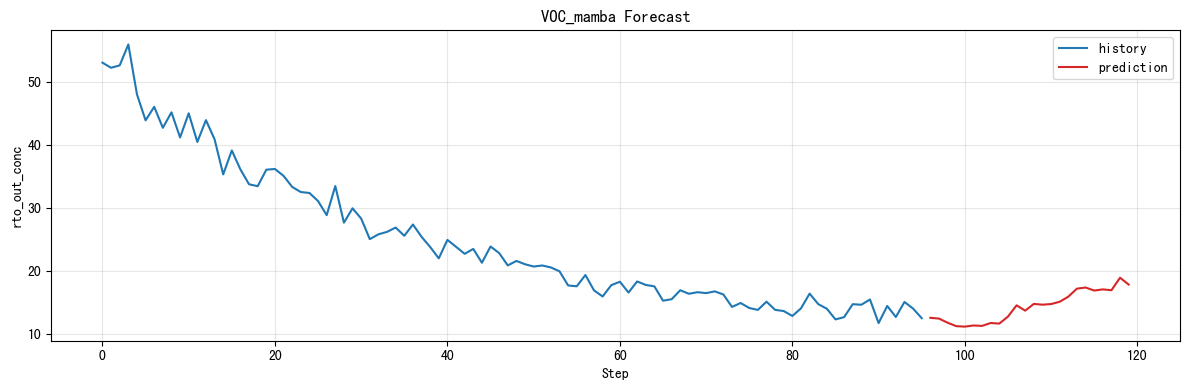

In [21]:
predictor = VOCSMambaPredictor(
    data_config=DataConfig(
        seq_len=SEQ_LEN,
        pred_len=PRED_LEN,
        checkpoint_path=model_dir / 'new_VOC_best.pt',
        scaler_path=model_dir / 'new_VOC_scalers.pkl',
    )
)
predictor.load()

batch_pred_df = predictor.predict_dataframe(df.tail(300).reset_index(drop=True), stride=4, show_progress=True)
display(batch_pred_df.head())

history_values = df[TARGET_COLUMN].tail(SEQ_LEN).tolist()
future_values = None
predicted_values = batch_pred_df.iloc[-1][[f't+{i}' for i in range(1, PRED_LEN + 1)]].tolist()
fig = plot_prediction_window(history_values, future_values, predicted_values, log_dir / 'prediction_window.png')
plt.show()

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

## 6. 与 VOCS 基线 LSTM 统一时序切分对比

将 `compare_with_vocs_baseline.py` 集成到 notebook 工作流中。

运行下一个代码单元后会：
- 使用当前 notebook 训练得到的 `new_VOC_best.pt` 与 `new_VOC_scalers.pkl`
- 加载 VOCS 原始 LSTM 基线模型与 scaler
- 在相同时间切分下计算并打印对比指标
- 保存对比结果到 `artifacts_notebook/logs/baseline_comparison.json`

In [11]:
from pathlib import Path
import sys

import numpy.core.numeric as _np_core_numeric
from compare_with_vocs_baseline import evaluate_baseline_lstm, evaluate_mamba, print_comparison

# Compatibility shim for scaler pickle created under another NumPy internal module path.
sys.modules.setdefault('numpy._core.numeric', _np_core_numeric)

baseline_checkpoint = Path('../VOCS/src/outputs/20260203_105917/models/vocs_seq2seq_v2_best.pth').resolve()
baseline_scaler = Path('../VOCS/src/outputs/20260203_105917/models/vocs_scalers_v2.pkl').resolve()
comparison_output = log_dir / 'baseline_comparison.json'

if not baseline_checkpoint.exists():
    raise FileNotFoundError(f'Baseline checkpoint not found: {baseline_checkpoint}')
if not baseline_scaler.exists():
    raise FileNotFoundError(f'Baseline scaler not found: {baseline_scaler}')

mamba_result = evaluate_mamba(
    dataset_df=df,
    data_config=data_config,
    checkpoint_path=model_dir / 'new_VOC_best.pt',
    scaler_path=model_dir / 'new_VOC_scalers.pkl',
    device=device,
)

baseline_result = evaluate_baseline_lstm(
    dataset_df=df,
    data_config=data_config,
    checkpoint_path=baseline_checkpoint,
    scaler_path=baseline_scaler,
    device=device,
)

comparison = {
    'dataset': str(data_config.dataset_csv),
    'device': str(device),
    'baseline_lstm': baseline_result,
    'mamba': mamba_result,
}

comparison_output.parent.mkdir(parents=True, exist_ok=True)
with open(comparison_output, 'w', encoding='utf-8') as handle:
    json.dump(comparison, handle, ensure_ascii=False, indent=2)

print_comparison(mamba_result, baseline_result)

summary_keys = [
    'avg_r2',
    'avg_mae',
    'avg_rmse',
    'trend_accuracy',
    'exceed_accuracy',
    'short_r2',
    'medium_r2',
    'long_r2',
]
comparison_df = pd.DataFrame(
    {
        'metric': summary_keys,
        'baseline_lstm': [baseline_result['summary'][k] for k in summary_keys],
        'mamba': [mamba_result['summary'][k] for k in summary_keys],
    }
)
comparison_df['delta(m-b)'] = comparison_df['mamba'] - comparison_df['baseline_lstm']

display(comparison_df)
print(f'Saved comparison JSON to {comparison_output}')

/usr/local/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



Shared-split comparison
------------------------------------------------------------------------
metric                baseline_lstm            mamba       delta(m-b)
------------------------------------------------------------------------
avg_r2                     0.650651         0.609076        -0.041575
avg_mae                    0.071812         0.070118        -0.001694
avg_rmse                   0.092415         0.099433         0.007019
trend_accuracy             0.629275         0.624596        -0.004679
exceed_accuracy            0.994175         0.994101        -0.000074
short_r2                   0.903064         0.900684        -0.002380
medium_r2                  0.646452         0.602190        -0.044261
long_r2                    0.402437         0.324355        -0.078082


,metric,baseline_lstm,mamba,delta(m-b)
0,avg_r2,0.650651,0.609076,-0.041575
1,avg_mae,0.071812,0.070118,-0.001694
2,avg_rmse,0.092415,0.099433,0.007019
3,trend_accuracy,0.629275,0.624596,-0.004679
4,exceed_accuracy,0.994175,0.994101,-0.000074
5,short_r2,0.903064,0.900684,-0.002380
6,medium_r2,0.646452,0.602190,-0.044261
7,long_r2,0.402437,0.324355,-0.078082


Saved comparison JSON to /output/服务外包大赛/new_VOC/artifacts_notebook/logs/baseline_comparison.json
